# 03 — Concept Drift Detection
> Detect real distributional changes using PSI (Population Stability Index) and KS-Test. Simulate 3 realistic drift scenarios: feature noise, class ratio shift, magnitude shift.

In [1]:
# Load model and reference data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Load data and model
df = pd.read_csv("creditcard.csv")
df_sorted = df.sort_values('Time').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

X_train = df_sorted.iloc[:split_idx].drop("Class", axis=1)
y_train = df_sorted.iloc[:split_idx]["Class"]
X_test  = df_sorted.iloc[split_idx:].drop("Class", axis=1)
y_test  = df_sorted.iloc[split_idx:]["Class"]

scaler     = joblib.load("models/scaler.pkl")
model      = joblib.load("models/best_model.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

with open("outputs/baseline_metrics.json") as f:
    baseline = json.load(f)

baseline_auc = baseline['roc_auc']
print(f"Baseline ROC-AUC: {baseline_auc}")
print(f"Test set: {len(X_test)} records | Fraud: {y_test.sum()}")


Baseline ROC-AUC: 0.9445
Test set: 56962 records | Fraud: 75


In [2]:
# PSI and KS-Test drift detection functions
# ================================================================
# DRIFT DETECTION ALGORITHMS
# ================================================================

def compute_psi(expected, actual, buckets=10):
    """Population Stability Index — industry standard drift metric"""
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 2:
        return 0.0
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_pct = np.where(exp_pct == 0, 1e-4, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-4, act_pct)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

def compute_ks(reference, current):
    """Kolmogorov–Smirnov test — p-value < 0.05 means significant drift"""
    ks_stat, p_value = stats.ks_2samp(reference, current)
    return float(ks_stat), float(p_value)

def drift_severity(psi):
    if psi < 0.1:
        return "STABLE", "green"
    elif psi < 0.2:
        return "MODERATE", "orange"
    else:
        return "HIGH", "red"

print("Drift detection functions ready")
print("PSI thresholds: <0.1 Stable | 0.1-0.2 Moderate | >0.2 High Drift")
print("KS  thresholds: p-value < 0.05 = statistically significant drift")


Drift detection functions ready
PSI thresholds: <0.1 Stable | 0.1-0.2 Moderate | >0.2 High Drift
KS  thresholds: p-value < 0.05 = statistically significant drift


In [3]:
# Scenario 1 — Feature distribution drift
# ================================================================
# DRIFT SCENARIO 1: Feature Distribution Shift (Gaussian noise)
# ================================================================
np.random.seed(42)
X_drift_s1 = X_test_scaled.copy()
X_drift_s1 += np.random.normal(0, 1.5, X_drift_s1.shape)  # stronger noise
y_drift_s1  = y_test.values

# PSI for key features
key_features = ['V1', 'V2', 'V3', 'V4', 'V14', 'V17', 'Amount']
feature_cols = list(X_train.columns)

psi_results_s1 = {}
ks_results_s1  = {}
for feat in key_features:
    idx = feature_cols.index(feat)
    psi_results_s1[feat] = compute_psi(X_train_scaled[:, idx], X_drift_s1[:, idx])
    ks_stat, ks_p = compute_ks(X_train_scaled[:, idx], X_drift_s1[:, idx])
    ks_results_s1[feat] = {'ks_stat': round(ks_stat, 4), 'p_value': round(ks_p, 6)}

psi_df_s1 = pd.DataFrame({
    'Feature': key_features,
    'PSI': [psi_results_s1[f] for f in key_features],
    'KS_stat': [ks_results_s1[f]['ks_stat'] for f in key_features],
    'KS_pvalue': [ks_results_s1[f]['p_value'] for f in key_features]
})
psi_df_s1['Severity'] = psi_df_s1['PSI'].apply(lambda x: drift_severity(x)[0])

print("Scenario 1 — Feature Distribution Drift:")
print(psi_df_s1.to_string(index=False))

# Model performance after drift
s1_proba = model.predict_proba(X_drift_s1)[:, 1]
s1_pred  = model.predict(X_drift_s1)
s1_auc   = roc_auc_score(y_drift_s1, s1_proba)
s1_drop  = baseline_auc - s1_auc
print(f"\nAUC drop: {baseline_auc:.4f} → {s1_auc:.4f}  (Δ = {s1_drop:+.4f})")


Scenario 1 — Feature Distribution Drift:
Feature      PSI  KS_stat  KS_pvalue Severity
     V1 0.634104   0.2835        0.0     HIGH
     V2 0.879748   0.2311        0.0     HIGH
     V3 0.642077   0.2764        0.0     HIGH
     V4 0.469956   0.1814        0.0     HIGH
    V14 0.644770   0.2158        0.0     HIGH
    V17 0.661923   0.2239        0.0     HIGH
 Amount 2.198021   0.4377        0.0     HIGH

AUC drop: 0.9445 → 0.9342  (Δ = +0.0103)


In [4]:
# Scenario 2 — Class ratio shift (fraud rate doubles)
# ================================================================
# DRIFT SCENARIO 2: Class Ratio Shift (fraud rate changes)
# ================================================================
# Simulate fraud rate doubling (real-world: new fraud ring detected)
y_test_arr = y_test.values
normal_idx = np.where(y_test_arr == 0)[0]
fraud_idx  = np.where(y_test_arr == 1)[0]

# Duplicate fraud samples (simulate increased fraud rate)
extra_fraud_idx = np.random.choice(fraud_idx, size=len(fraud_idx), replace=True)
new_idx = np.concatenate([normal_idx, fraud_idx, extra_fraud_idx])
np.random.shuffle(new_idx)

X_drift_s2 = X_test_scaled[new_idx]
y_drift_s2 = y_test_arr[new_idx]

print(f"Scenario 2 — Class Ratio Shift:")
print(f"  Original fraud rate: {y_test_arr.mean()*100:.3f}%")
print(f"  Drifted fraud rate:  {y_drift_s2.mean()*100:.3f}% (doubled)")

s2_proba = model.predict_proba(X_drift_s2)[:, 1]
s2_pred  = model.predict(X_drift_s2)
s2_auc   = roc_auc_score(y_drift_s2, s2_proba)
s2_pr    = average_precision_score(y_drift_s2, s2_proba)
s2_recall = classification_report(y_drift_s2, s2_pred, output_dict=True)['1']['recall']

print(f"\nAUC: {s2_auc:.4f} | PR-AUC: {s2_pr:.4f} | Fraud Recall: {s2_recall:.4f}")
print(f"AUC drop: {baseline_auc:.4f} → {s2_auc:.4f}  (Δ = {baseline_auc - s2_auc:+.4f})")


Scenario 2 — Class Ratio Shift:
  Original fraud rate: 0.132%
  Drifted fraud rate:  0.263% (doubled)

AUC: 0.9516 | PR-AUC: 0.8379 | Fraud Recall: 0.6867
AUC drop: 0.9445 → 0.9516  (Δ = -0.0071)


In [5]:
# Scenario 3 — Severe combined drift
# ================================================================
# DRIFT SCENARIO 3: Combined severe drift (magnitude + noise)
# ================================================================
X_drift_s3 = X_test_scaled.copy()
X_drift_s3 += np.random.normal(0, 2.5, X_drift_s3.shape)   # heavy noise
X_drift_s3 *= np.random.uniform(0.6, 1.4, X_drift_s3.shape) # magnitude shift
y_drift_s3  = y_test.values

psi_s3_v14 = compute_psi(X_train_scaled[:, feature_cols.index('V14')],
                          X_drift_s3[:, feature_cols.index('V14')])
s3_proba = model.predict_proba(X_drift_s3)[:, 1]
s3_pred  = model.predict(X_drift_s3)
s3_auc   = roc_auc_score(y_drift_s3, s3_proba)

print(f"Scenario 3 — Severe Combined Drift:")
print(f"  V14 PSI: {psi_s3_v14:.4f} (severity: {drift_severity(psi_s3_v14)[0]})")
print(f"  AUC: {baseline_auc:.4f} → {s3_auc:.4f}  (Δ = {baseline_auc - s3_auc:+.4f})")


Scenario 3 — Severe Combined Drift:
  V14 PSI: 1.1226 (severity: HIGH)
  AUC: 0.9445 → 0.8867  (Δ = +0.0578)


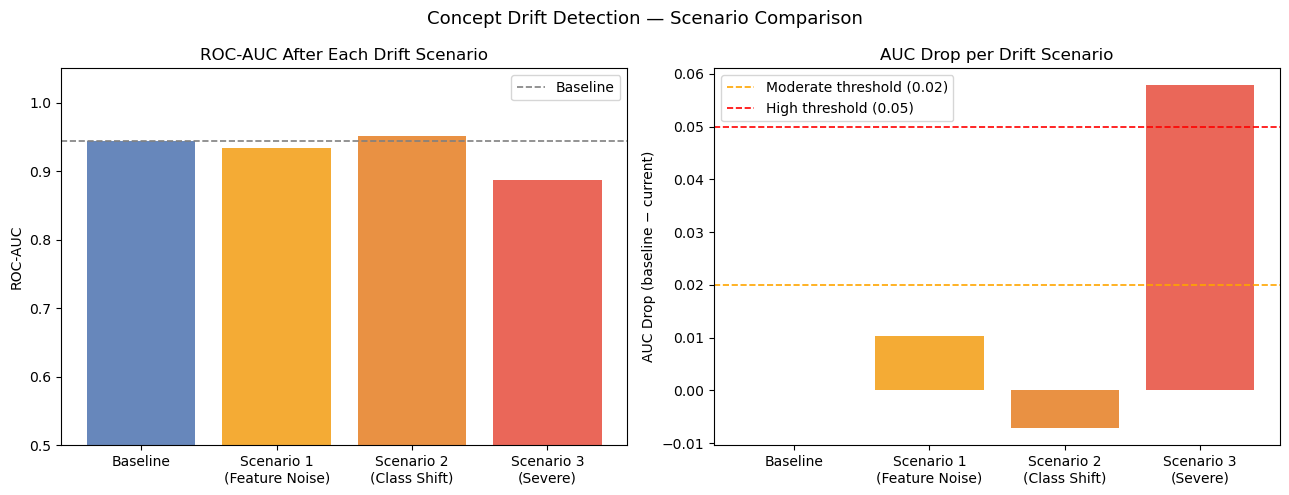

Drift arrays saved for NB05 self-healing pipeline.


In [6]:
# Drift summary dashboard + save scenarios
# ================================================================
# DRIFT SUMMARY DASHBOARD
# ================================================================
scenarios = {
    'Baseline':   {'auc': baseline_auc, 'drop': 0.0,                        'severity': 'NONE'},
    'Scenario 1\n(Feature Noise)': {
        'auc': s1_auc, 'drop': baseline_auc - s1_auc,
        'severity': 'HIGH' if (baseline_auc - s1_auc) > 0.02 else 'MODERATE'
    },
    'Scenario 2\n(Class Shift)': {
        'auc': s2_auc, 'drop': baseline_auc - s2_auc,
        'severity': 'HIGH' if (baseline_auc - s2_auc) > 0.02 else 'MODERATE'
    },
    'Scenario 3\n(Severe)': {
        'auc': s3_auc, 'drop': baseline_auc - s3_auc,
        'severity': 'HIGH'
    },
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names  = list(scenarios.keys())
aucs   = [v['auc']  for v in scenarios.values()]
drops  = [v['drop'] for v in scenarios.values()]
colors = ['#4C72B0', '#f39c12', '#e67e22', '#e74c3c']

axes[0].bar(names, aucs,  color=colors, alpha=0.85)
axes[0].axhline(baseline_auc, color='gray', linestyle='--', linewidth=1.2, label='Baseline')
axes[0].set_title("ROC-AUC After Each Drift Scenario")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()

axes[1].bar(names, drops, color=colors, alpha=0.85)
axes[1].axhline(0.02, color='orange', linestyle='--', linewidth=1.2, label='Moderate threshold (0.02)')
axes[1].axhline(0.05, color='red',    linestyle='--', linewidth=1.2, label='High threshold (0.05)')
axes[1].set_title("AUC Drop per Drift Scenario")
axes[1].set_ylabel("AUC Drop (baseline − current)")
axes[1].legend()

plt.suptitle("Concept Drift Detection — Scenario Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/03_drift_scenarios.png", dpi=120, bbox_inches='tight')
plt.show()

# Save drift metadata for NB05
import json
drift_data = {
    'scenario_1': {'X': X_drift_s1.tolist()[:100], 'auc': s1_auc, 'drop': float(baseline_auc - s1_auc)},
    'scenario_3': {'X': X_drift_s3.tolist()[:100], 'auc': s3_auc, 'drop': float(baseline_auc - s3_auc)},
}
# Save full arrays via numpy for NB05 to load
np.save("outputs/X_drift_s1.npy", X_drift_s1)
np.save("outputs/y_drift_s1.npy", y_drift_s1)
np.save("outputs/X_drift_s3.npy", X_drift_s3)
np.save("outputs/y_drift_s3.npy", y_drift_s3)
np.save("outputs/X_drift_s2.npy", X_drift_s2)
np.save("outputs/y_drift_s2.npy", y_drift_s2)
print("Drift arrays saved for NB05 self-healing pipeline.")
